In [2]:
import os 
os.chdir("D:/Myprojects/CustomerSegmentation")

In [7]:
#Importing Required Libraries 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Data collection and inspection 
df  = pd.read_csv("ecommerce_website_cus_data.csv")
print(df.info())
print(df.head(3))
print(df.describe())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CustomerID           20000 non-null  int64 
 1   Age                  20000 non-null  int64 
 2   Gender               20000 non-null  object
 3   City                 20000 non-null  object
 4   AnnualIncome         20000 non-null  int64 
 5   SpendingScore        20000 non-null  int64 
 6   PurchaseAmount       20000 non-null  int64 
 7   PurchaseFrequency    20000 non-null  int64 
 8   ProductCategory      20000 non-null  object
 9   LastPurchaseDaysAgo  20000 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 1.5+ MB
None
   CustomerID  Age Gender       City  AnnualIncome  SpendingScore  \
0       10001   56   Male       Pune       1181408              8   
1       10002   46   Male  Bangalore        847110             14   
2       10003   32   Male      Delhi     

In [8]:
# Data preprocessing 
print(df.isnull().sum())

#label encoding 
df1  = pd.get_dummies(df,columns=['ProductCategory'])

CustomerID             0
Age                    0
Gender                 0
City                   0
AnnualIncome           0
SpendingScore          0
PurchaseAmount         0
PurchaseFrequency      0
ProductCategory        0
LastPurchaseDaysAgo    0
dtype: int64


In [10]:
#feature enginering
#feature selection 
X   = df1.drop(columns=['CustomerID','Age','Gender','City',"AnnualIncome",'SpendingScore','PurchaseFrequency'])

#scaling 
scaler  = StandardScaler()
X_scaled  = scaler.fit_transform(X)

# modeling 
model  = KMeans(n_clusters=4,random_state=42,n_init=10)

#segmentation
df1['cluster']  = model.fit_predict(X_scaled)

#Business Insights
print("Following are the type of customers who categorized and ranked based on their spending behavior and product category , ")
customers_category = df1['cluster'].value_counts()
print(customers_category)

Following are the type of customers who categorized and ranked based on their spending behavior and product category , 
cluster
1    9941
0    3398
2    3343
3    3318
Name: count, dtype: int64


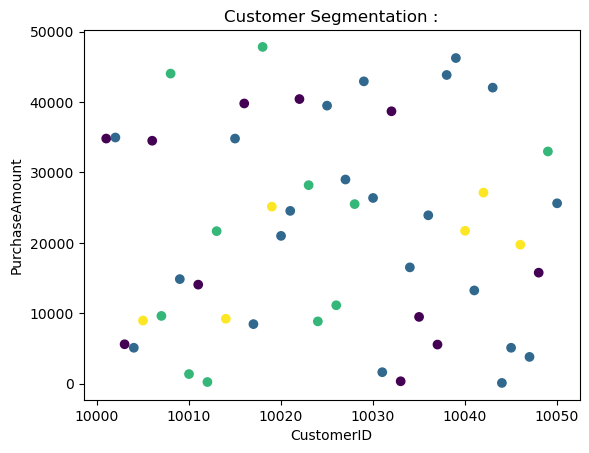

In [11]:
#visualization 
plt.scatter(df1['CustomerID'].head(50),df1['PurchaseAmount'].head(50), c = df1['cluster'].head(50))
plt.title("Customer Segmentation :")
plt.xlabel("CustomerID")
plt.ylabel("PurchaseAmount")
plt.show()